https://colab.research.google.com/drive/1-u-1d4e8NyNmSL0de2-J1CFWkLBF_ybb?usp=sharing

In [ ]:
!gdown 1F9aD344ifJiKzRDlR4ZX0e4plDuP9-b9

Downloading...
From: https://drive.google.com/uc?id=1F9aD344ifJiKzRDlR4ZX0e4plDuP9-b9
To: /content/kaggle_houseprices_modified.csv
100% 459k/459k [00:00<00:00, 8.24MB/s]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/kaggle_houseprices_modified.csv')

In [ ]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,198075.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,199650.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,212325.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,237500.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# Looking at the distribution of the target will always give an indication of the challenge at hand

<Axes: xlabel='SalePrice', ylabel='Count'>

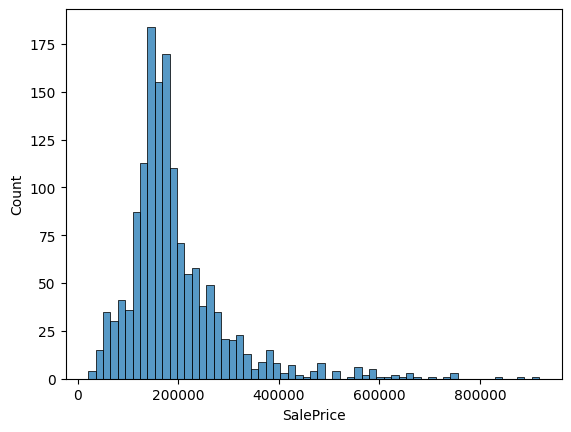

In [ ]:
sns.histplot(df['SalePrice'])

In [ ]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,198075.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,199650.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,212325.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,237500.0


# Some questions to ask ourselves:
# 1. Whichc columns do we drop based on nulls?
# 2. How to replace nulls?
# 3. What type of encoding to use for categorical variables?
# 4. What kind of features can we create?


# I want to see nulls as a percentage

In [ ]:
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
...,...
MoSold,0.000000
YrSold,0.000000
SaleType,0.000000
SaleCondition,0.000000


# Instead of blindly dropping features with too many nulls, I want to first study them

In [ ]:
df['PoolQC'].unique()

array([nan, 'Ex', 'Fa', 'Gd'], dtype=object)

In [ ]:
df['PoolQC'].fillna('NA',inplace=True)

/tmp/ipykernel_7949/2985270662.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PoolQC'].fillna('NA',inplace=True)


In [ ]:
df['MiscFeature'].unique()

array([nan, 'Shed', 'Gar2', 'Othr', 'TenC'], dtype=object)

In [ ]:
df['MiscFeature'].fillna('NA',inplace=True)

/tmp/ipykernel_7949/3114602387.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MiscFeature'].fillna('NA',inplace=True)


In [ ]:
df['Alley'].unique()

array([nan, 'Grvl', 'Pave'], dtype=object)

In [ ]:
df['Alley'].fillna('NA',inplace=True)

/tmp/ipykernel_7949/1775317.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Alley'].fillna('NA',inplace=True)


In [ ]:
df['Fence'].unique()

array([nan, 'MnPrv', 'GdWo', 'GdPrv', 'MnWw'], dtype=object)

In [ ]:
df['Fence'].fillna('NA',inplace=True)

/tmp/ipykernel_7949/1188956341.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Fence'].fillna('NA',inplace=True)


# There are other features with fewer nulls - i have two options - use iterative imuputer or let the model handle them

# Start creating features with time based columns


In [ ]:
df[['YrSold','YearBuilt','YrSold','GarageYrBlt','MoSold','YearRemodAdd']]

,YrSold,YearBuilt,YrSold,GarageYrBlt,MoSold,YearRemodAdd
0,2008,2003,2008,2003.0,2,2003
1,2007,1976,2007,1976.0,5,1976
2,2008,2001,2008,2001.0,9,2002
3,2006,1915,2006,1998.0,2,1970
4,2008,2000,2008,2000.0,12,2000
...,...,...,...,...,...,...
1455,2007,1999,2007,1999.0,8,2000
1456,2010,1978,2010,1978.0,2,1988
1457,2010,1941,2010,1941.0,5,2006
1458,2010,1950,2010,1950.0,4,1996


In [ ]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['GarageAge'] = df['YrSold'] - df['GarageYrBlt']

In [ ]:
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
df['IsRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)

# There is one more type of feature that is powerful but people miss out

In [ ]:
df = df.sort_values('YrSold')

In [ ]:
year_mean = df.groupby('YrSold')['SalePrice'].mean()

# Step 2: shift by 1 year (previous year)
prev_year_mean = year_mean.shift(1)

# Step 3: map back to rows
df['AvgPricePrevYear'] = df['YrSold'].map(prev_year_mean)

In [ ]:
year_mean

,SalePrice
YrSold,
2006,201990.630892
2007,203071.150000
2008,184753.708224
2009,189331.716272
2010,185891.686857


In [ ]:
prev_year_mean

,SalePrice
YrSold,
2006,NaN
2007,201990.630892
2008,203071.150000
2009,184753.708224
2010,189331.716272


In [ ]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HouseAge,GarageAge,RemodAge,IsRemodeled,AvgPricePrevYear
342,343,90,RL,NaN,8544,Pave,NA,Reg,Lvl,AllPub,...,5,2006,WD,Normal,87500.0,57,57.0,56,1,NaN
1265,1266,160,FV,35.0,3735,Pave,NA,Reg,Lvl,AllPub,...,3,2006,WD,Normal,174705.0,7,7.0,7,0,NaN
338,339,20,RL,91.0,14145,Pave,NA,Reg,Lvl,AllPub,...,5,2006,WD,Normal,202500.0,22,22.0,8,1,NaN
370,371,60,RL,NaN,8121,Pave,NA,IR1,Lvl,AllPub,...,1,2006,WD,Normal,163780.0,6,6.0,6,0,NaN
364,365,60,RL,NaN,18800,Pave,NA,IR1,Lvl,AllPub,...,7,2006,WD,Normal,180500.0,30,30.0,30,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,911,90,RL,80.0,11600,Pave,NA,Reg,Lvl,AllPub,...,1,2010,WD,Normal,154300.0,50,50.0,50,0,189331.716272
949,950,20,RL,78.0,9360,Pave,NA,Reg,Lvl,AllPub,...,3,2010,WD,Normal,217250.0,38,38.0,4,1,189331.716272
959,960,160,FV,24.0,2572,Pave,NA,Reg,Lvl,AllPub,...,5,2010,WD,Normal,147250.0,11,11.0,11,0,189331.716272
960,961,20,RL,50.0,7207,Pave,NA,IR1,Lvl,AllPub,...,2,2010,WD,Normal,69900.0,52,NaN,2,1,189331.716272


# Next , we need to encode categorical features

#

# Now, let us split our data. But why are we splitting so soon?

# Since there clearly is a time based feature, doesnt it make sense to have a time based split instead of random split? - explained in notes

In [ ]:
year_counts = df['YrSold'].value_counts().sort_index()
year_counts

,count
YrSold,
2006,314
2007,329
2008,304
2009,338
2010,175


In [ ]:
df_sorted = df.sort_values('YrSold').reset_index(drop=True)

# 2️⃣ Compute split index
split_idx = int(0.8 * len(df_sorted))

# 3️⃣ Train / test split
train_df = df_sorted.iloc[:split_idx]
test_df  = df_sorted.iloc[split_idx:]

In [ ]:
# train_df = df[df['YrSold'] < 2010]
# test_df  = df[df['YrSold'] >= 2010]

# Next let us see how to handle categorical variables - explained in notes

# Let us check number of categories in each categorical variables.

In [ ]:
cat_cols = train_df.select_dtypes(include='object').columns

cat_cardinality = train_df[cat_cols].nunique().sort_values(ascending=False)
cat_cardinality

,0
Neighborhood,25
Exterior2nd,16
Exterior1st,14
Condition1,9
SaleType,9
HouseStyle,8
RoofMatl,8
Condition2,8
Functional,7
BsmtFinType2,6


In [ ]:
low_card_cols = cat_cardinality[cat_cardinality <= 2].index.tolist()

low_card_cols

['Street', 'Utilities', 'CentralAir']

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

ohe.fit(train_df[low_card_cols])


OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [ ]:
train_ohe = ohe.transform(train_df[low_card_cols])
test_ohe  = ohe.transform(test_df[low_card_cols])

In [ ]:
test_ohe

array([[0., 1., 1., 0., 1., 0.],
       [0., 1., 1., 0., 0., 1.],
       [0., 1., 1., 0., 0., 1.],
       ...,
       [0., 1., 1., 0., 0., 1.],
       [0., 1., 1., 0., 0., 1.],
       [0., 1., 1., 0., 0., 1.]])

In [ ]:
ohe_cols = ohe.get_feature_names_out(low_card_cols)

train_ohe_df = pd.DataFrame(train_ohe, columns=ohe_cols, index=train_df.index)
test_ohe_df  = pd.DataFrame(test_ohe, columns=ohe_cols, index=test_df.index)


In [ ]:
train_ohe_df

,Street_Grvl,Street_Pave,Utilities_AllPub,Utilities_NoSeWa,CentralAir_N,CentralAir_Y
0,0.0,1.0,1.0,0.0,0.0,1.0
1,0.0,1.0,1.0,0.0,0.0,1.0
2,0.0,1.0,1.0,0.0,0.0,1.0
3,0.0,1.0,1.0,0.0,0.0,1.0
4,0.0,1.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...
1163,0.0,1.0,1.0,0.0,0.0,1.0
1164,0.0,1.0,1.0,0.0,0.0,1.0
1165,0.0,1.0,1.0,0.0,0.0,1.0
1166,0.0,1.0,1.0,0.0,0.0,1.0


In [ ]:
test_ohe_df.head()

,Street_Grvl,Street_Pave,Utilities_AllPub,Utilities_NoSeWa,CentralAir_N,CentralAir_Y
1168,0.0,1.0,1.0,0.0,1.0,0.0
1169,0.0,1.0,1.0,0.0,0.0,1.0
1170,0.0,1.0,1.0,0.0,0.0,1.0
1171,0.0,1.0,1.0,0.0,0.0,1.0
1172,0.0,1.0,1.0,0.0,0.0,1.0


# Next, lets handle medium/high cardinality categorical columns

In [ ]:
medium_card_cols = cat_cardinality[(cat_cardinality <= 10)&(cat_cardinality > 2)].index.tolist()

medium_card_cols

['Condition1',
 'SaleType',
 'HouseStyle',
 'RoofMatl',
 'Condition2',
 'Functional',
 'BsmtFinType2',
 'RoofStyle',
 'BsmtFinType1',
 'SaleCondition',
 'Heating',
 'Foundation',
 'GarageType',
 'BldgType',
 'LotConfig',
 'MSZoning',
 'MiscFeature',
 'Fence',
 'GarageCond',
 'Electrical',
 'HeatingQC',
 'FireplaceQu',
 'GarageQual',
 'LotShape',
 'PoolQC',
 'BsmtExposure',
 'BsmtQual',
 'KitchenQual',
 'LandContour',
 'BsmtCond',
 'ExterQual',
 'ExterCond',
 'MasVnrType',
 'GarageFinish',
 'Alley',
 'LandSlope',
 'PavedDrive']

In [ ]:
# Step 2: create empty DataFrames for encoded features
target_col = 'SalePrice'
train_te = pd.DataFrame(index=train_df.index)
test_te  = pd.DataFrame(index=test_df.index)

# Step 3: compute target encoding for each medium-card column
for col in medium_card_cols:
    # Compute mean SalePrice per category
    mean_target = train_df.groupby(col)[target_col].mean()

    # Map to train
    train_te[f'{col}_te'] = train_df[col].map(mean_target)

    # Map to test, fill unseen categories with global mean
    test_te[f'{col}_te'] = test_df[col].map(mean_target)

# Step 4: join encoded features back to original DataFrames
train_df = pd.concat([train_df, train_te], axis=1)
test_df  = pd.concat([test_df, test_te], axis=1)

In [ ]:
test_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,KitchenQual_te,LandContour_te,BsmtCond_te,ExterQual_te,ExterCond_te,MasVnrType_te,GarageFinish_te,Alley_te,LandSlope_te,PavedDrive_te
1168,585,50,RM,51.0,6120,Pave,NA,Reg,Lvl,AllPub,...,232619.149785,195067.881753,197962.517973,150042.315534,199229.791028,NaN,153535.856485,198801.867844,195728.557059,203196.631946
1169,230,120,RL,43.0,3182,Pave,NA,Reg,Lvl,AllPub,...,232619.149785,195067.881753,197962.517973,254246.174369,199229.791028,218816.908028,263342.648785,198801.867844,195728.557059,203196.631946
1170,1123,20,RL,NaN,8926,Pave,NA,IR1,Lvl,AllPub,...,145484.921599,195067.881753,197962.517973,150042.315534,199229.791028,NaN,153535.856485,198801.867844,195728.557059,203196.631946
1171,505,160,RL,24.0,2308,Pave,NA,Reg,Lvl,AllPub,...,145484.921599,195067.881753,197962.517973,150042.315534,199229.791028,NaN,153535.856485,198801.867844,195728.557059,203196.631946
1172,506,90,RM,60.0,7596,Pave,Grvl,Reg,Lvl,AllPub,...,145484.921599,195067.881753,197962.517973,150042.315534,199229.791028,218816.908028,153535.856485,126645.916279,195728.557059,110799.575342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,911,90,RL,80.0,11600,Pave,NA,Reg,Lvl,AllPub,...,145484.921599,195067.881753,197962.517973,150042.315534,199229.791028,218816.908028,153535.856485,198801.867844,195728.557059,203196.631946
1456,950,20,RL,78.0,9360,Pave,NA,Reg,Lvl,AllPub,...,232619.149785,195067.881753,197962.517973,150042.315534,199229.791028,NaN,223322.006825,198801.867844,195728.557059,203196.631946
1457,960,160,FV,24.0,2572,Pave,NA,Reg,Lvl,AllPub,...,232619.149785,195067.881753,197962.517973,254246.174369,199229.791028,NaN,153535.856485,198801.867844,195728.557059,203196.631946
1458,961,20,RL,50.0,7207,Pave,NA,IR1,Lvl,AllPub,...,145484.921599,195067.881753,197962.517973,150042.315534,180982.631579,NaN,NaN,198801.867844,195728.557059,203196.631946


In [ ]:
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice', 'HouseAge', 'GarageAge',
       'RemodAge', 'IsRemodeled', 'AvgPricePrevYear', 'Condition1_te',
       'SaleType_te', 'HouseStyle_te', 'RoofMatl_te', 'Condition2_te',
       'Functional_te', 'BsmtFinType2_te', 'RoofStyle_te', 'BsmtFinType1_te',
       'SaleCondition_te', 'Heating_te', 'Foundation_te', 'GarageType_te',
       'BldgType_te', 'LotConfig_te', 'MSZoning_te', 'MiscFeature_te',
       'Fence_te', 'GarageCond_te'

# Lets create feature aggregate encodings!


In [ ]:
high_card_cols = cat_cardinality[cat_cardinality > 10].index.tolist()

high_card_cols

['Neighborhood', 'Exterior2nd', 'Exterior1st']

In [ ]:
numeric_cols = ['OverallQual', 'TotRmsAbvGrd', 'GarageArea', 'PoolArea', 'SalePrice', 'HouseAge']

# 1️⃣ Neighborhood embeddings
Neighborhood_embeddings = train_df.groupby('Neighborhood')[numeric_cols].mean().reset_index()
# Rename numeric columns
Neighborhood_embeddings = Neighborhood_embeddings.rename(
    columns={col: f'Neighborhood_{col}_mean' for col in numeric_cols}
)
# Add popularity
popularity = train_df['Neighborhood'].value_counts(normalize=True)
Neighborhood_embeddings['Neighborhood_popularity'] = Neighborhood_embeddings['Neighborhood'].map(popularity)

# 2️⃣ Exterior2nd embeddings
Exterior2nd_embeddings = train_df.groupby('Exterior2nd')[numeric_cols].mean().reset_index()
Exterior2nd_embeddings = Exterior2nd_embeddings.rename(
    columns={col: f'Exterior2nd_{col}_mean' for col in numeric_cols}
)
popularity = train_df['Exterior2nd'].value_counts(normalize=True)
Exterior2nd_embeddings['Exterior2nd_popularity'] = Exterior2nd_embeddings['Exterior2nd'].map(popularity)

# 3️⃣ Exterior1st embeddings
Exterior1st_embeddings = train_df.groupby('Exterior1st')[numeric_cols].mean().reset_index()
Exterior1st_embeddings = Exterior1st_embeddings.rename(
    columns={col: f'Exterior1st_{col}_mean' for col in numeric_cols}
)
popularity = train_df['Exterior1st'].value_counts(normalize=True)
Exterior1st_embeddings['Exterior1st_popularity'] = Exterior1st_embeddings['Exterior1st'].map(popularity)

# Quick check
Neighborhood_embeddings.head()


,Neighborhood,Neighborhood_OverallQual_mean,Neighborhood_TotRmsAbvGrd_mean,Neighborhood_GarageArea_mean,Neighborhood_PoolArea_mean,Neighborhood_SalePrice_mean,Neighborhood_HouseAge_mean,Neighborhood_popularity
0,Blmngtn,7.133333,6.400000,497.133333,0.0,231163.000000,2.000000,0.012842
1,Blueste,6.000000,6.000000,452.000000,0.0,151000.000000,28.000000,0.000856
2,BrDale,5.692308,5.769231,288.615385,0.0,100753.846154,35.923077,0.011130
3,BrkSide,5.000000,5.580000,308.940000,0.0,127233.250000,76.540000,0.042808
4,ClearCr,5.826087,6.869565,474.086957,0.0,208355.739130,41.217391,0.019692


In [ ]:
Exterior2nd_embeddings

,Exterior2nd,Exterior2nd_OverallQual_mean,Exterior2nd_TotRmsAbvGrd_mean,Exterior2nd_GarageArea_mean,Exterior2nd_PoolArea_mean,Exterior2nd_SalePrice_mean,Exterior2nd_HouseAge_mean,Exterior2nd_popularity
0,AsbShng,4.588235,6.411765,287.352941,0.000000,108213.652941,72.117647,0.014555
1,AsphShn,5.500000,6.000000,413.500000,0.000000,163950.000000,37.500000,0.001712
2,Brk Cmn,5.250000,6.250000,462.000000,0.000000,135550.000000,38.000000,0.003425
3,BrkFace,6.100000,6.200000,385.750000,0.000000,193314.000000,47.050000,0.017123
4,CBlock,4.000000,6.000000,338.000000,0.000000,115500.000000,89.000000,0.000856
5,CmentBd,7.045455,7.090909,549.568182,0.000000,283060.670455,19.954545,0.037671
6,HdBoard,5.918750,6.431250,465.781250,4.050000,172895.093750,33.825000,0.136986
7,ImStucc,6.888889,6.333333,626.666667,61.666667,271233.333333,20.888889,0.007705
8,MetalSd,5.556818,6.125000,421.068182,0.000000,158489.881818,50.602273,0.150685
9,Other,8.000000,7.000000,758.000000,0.000000,478500.000000,1.000000,0.000856


In [ ]:
train_df = train_df.merge(Neighborhood_embeddings, on='Neighborhood', how='left')

# Merge Exterior2nd embeddings
train_df = train_df.merge(Exterior2nd_embeddings, on='Exterior2nd', how='left')

# Merge Exterior1st embeddings
train_df = train_df.merge(Exterior1st_embeddings, on='Exterior1st', how='left')

In [ ]:
test_df = test_df.merge(Neighborhood_embeddings, on='Neighborhood', how='left')

# Merge Exterior2nd embeddings
test_df = test_df.merge(Exterior2nd_embeddings, on='Exterior2nd', how='left')

# Merge Exterior1st embeddings
test_df = test_df.merge(Exterior1st_embeddings, on='Exterior1st', how='left')

In [ ]:
len(train_df.columns)

143

In [ ]:
len(test_df.columns)

143

In [ ]:
train_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Exterior2nd_SalePrice_mean,Exterior2nd_HouseAge_mean,Exterior2nd_popularity,Exterior1st_OverallQual_mean,Exterior1st_TotRmsAbvGrd_mean,Exterior1st_GarageArea_mean,Exterior1st_PoolArea_mean,Exterior1st_SalePrice_mean,Exterior1st_HouseAge_mean,Exterior1st_popularity
0,350,60,RL,56.0,20431,Pave,NA,IR2,Lvl,AllPub,...,283060.670455,19.954545,0.037671,7.000000,7.066667,550.155556,0.000000,280503.766667,20.622222,0.038527
1,352,120,RL,NaN,5271,Pave,NA,IR1,Low,AllPub,...,157218.746405,67.019608,0.130993,5.639241,6.443038,376.202532,3.512658,160130.345570,67.455696,0.135274
2,355,50,RL,60.0,8400,Pave,NA,Reg,Bnk,AllPub,...,158489.881818,50.602273,0.150685,5.639241,6.443038,376.202532,3.512658,160130.345570,67.455696,0.135274
3,359,80,RL,92.0,6930,Pave,NA,IR1,Lvl,AllPub,...,271233.333333,20.888889,0.007705,5.639241,6.443038,376.202532,3.512658,160130.345570,67.455696,0.135274
4,360,60,RL,78.0,12011,Pave,NA,IR1,Lvl,AllPub,...,236760.863692,14.420538,0.350171,6.747596,6.790865,553.860577,0.000000,236996.756370,14.173077,0.356164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1163,550,60,FV,75.0,9375,Pave,NA,Reg,Lvl,AllPub,...,236760.863692,14.420538,0.350171,6.747596,6.790865,553.860577,0.000000,236996.756370,14.173077,0.356164
1164,1166,20,RL,79.0,9541,Pave,NA,IR1,Lvl,AllPub,...,236760.863692,14.420538,0.350171,6.747596,6.790865,553.860577,0.000000,236996.756370,14.173077,0.356164
1165,1158,120,RL,34.0,5001,Pave,NA,IR1,Lvl,AllPub,...,236760.863692,14.420538,0.350171,6.747596,6.790865,553.860577,0.000000,236996.756370,14.173077,0.356164
1166,543,20,RL,78.0,10140,Pave,NA,Reg,Lvl,AllPub,...,236760.863692,14.420538,0.350171,6.747596,6.790865,553.860577,0.000000,236996.756370,14.173077,0.356164


In [ ]:
target_col = 'SalePrice'
numeric_features = train_df.select_dtypes(include='number').columns.tolist()
numeric_features.remove(target_col)

# 2️⃣ Prepare train and test matrices
X_train = train_df[numeric_features]
y_train = train_df[target_col]

X_test = test_df[numeric_features]
y_test = test_df[target_col]

In [ ]:
X_train.drop(['Id'],axis=1,inplace=True)
X_test.drop(['Id'],axis=1,inplace=True)

/tmp/ipykernel_7949/2561188616.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop(['Id'],axis=1,inplace=True)
/tmp/ipykernel_7949/2561188616.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop(['Id'],axis=1,inplace=True)


# Ideally, would do grid search + cross validation.

In [ ]:
# import xgboost as xgb
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import mean_absolute_percentage_error, make_scorer

# # Custom MAPE scorer (lower is better → negate)
# mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

# param_grid = {
#     'max_depth': [3, 4, 5],
#     'learning_rate': [0.03, 0.05, 0.1],
#     'n_estimators': [300, 500, 700],
#     'subsample': [0.7, 0.8],
#     'colsample_bytree': [0.7, 0.8]
# }

# xgb_model = xgb.XGBRegressor(
#     objective='reg:squarederror',
#     random_state=42
# )

# grid_search = GridSearchCV(
#     estimator=xgb_model,
#     param_grid=param_grid,
#     scoring=mape_scorer,
#     cv=5,
#     n_jobs=-1,
#     verbose=2
# )

# grid_search.fit(X_train, y_train)

# best_model = grid_search.best_estimator_

# print("Best parameters:")
# print(grid_search.best_params_)

# # Predict on test
# y_pred = best_model.predict(X_test)

# # Test MAPE
# mape = mean_absolute_percentage_error(y_test, y_pred)
# print(f"Test MAPE: {mape:.4f}")

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# 4️⃣ Predict on test set
y_pred = xgb_model.predict(X_test)

# 5️⃣ Evaluate with MAPE
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE on test set: {mape:.4f}")

MAPE on test set: 0.0979


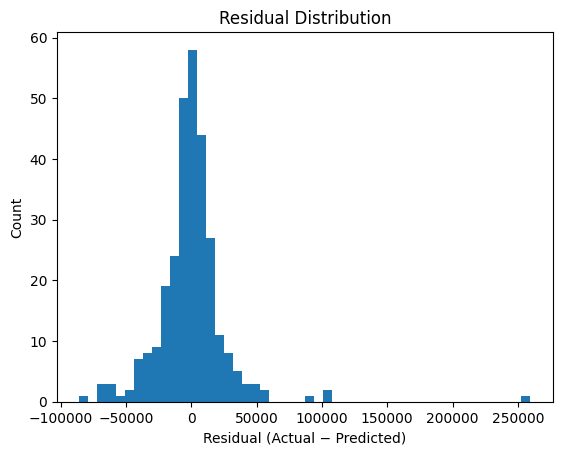

In [ ]:
residuals = y_test - y_pred
plt.figure()
plt.hist(residuals, bins=50)
plt.xlabel("Residual (Actual − Predicted)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.show()

# Observe how its right tailed (Actual greater than predicted) -  lot of underforecasting - costly homes are being predicted lesser

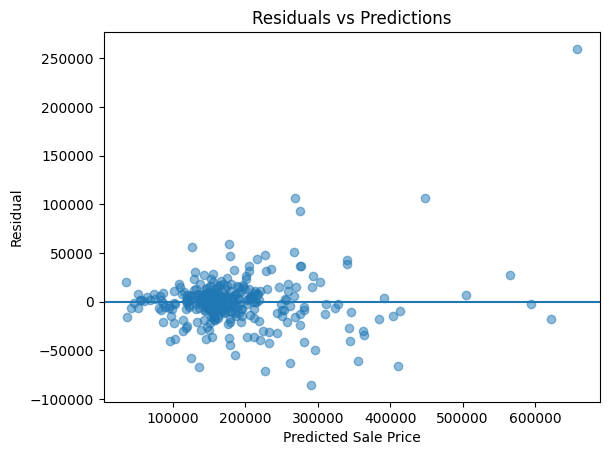

In [ ]:
plt.figure()
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0)
plt.xlabel("Predicted Sale Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predictions")
plt.show()

# We can observe outliers in sale price. They have high errors because there lack features that can capture the nature of anomalies.



# What can we do?

# Why not perform anomaly detection and pass it on as a feature

# Never perform anomaly detection on all features. It becomes meaningless. Perform only on features which you feel may directly impact price

In [ ]:
anomaly_features = [
    'OverallQual',
    'GrLivArea',
    'TotalBsmtSF',
    'GarageArea',
    'LotArea',
    'HouseAge'
]

from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

iso.fit(train_df[anomaly_features])

IsolationForest(contamination=0.05, n_estimators=300, random_state=42)

In [ ]:
train_df['anomaly_score'] = iso.decision_function(train_df[anomaly_features])

test_df['anomaly_score'] = iso.decision_function(test_df[anomaly_features])

In [ ]:
target_col = 'SalePrice'
numeric_features = train_df.select_dtypes(include='number').columns.tolist()
numeric_features.remove(target_col)

# 2️⃣ Prepare train and test matrices
X_train = train_df[numeric_features]
y_train = train_df[target_col]

X_test = test_df[numeric_features]
y_test = test_df[target_col]

In [ ]:
X_train.drop(['Id'],axis=1,inplace=True)
X_test.drop(['Id'],axis=1,inplace=True)

/tmp/ipykernel_7949/2561188616.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop(['Id'],axis=1,inplace=True)
/tmp/ipykernel_7949/2561188616.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop(['Id'],axis=1,inplace=True)


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# 4️⃣ Predict on test set
y_pred = xgb_model.predict(X_test)

# 5️⃣ Evaluate with MAPE
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE on test set: {mape:.4f}")

MAPE on test set: 0.0973


In [ ]:
import pandas as pd

booster = xgb_model.get_booster()

importance = (
    pd.Series(booster.get_score(importance_type='gain'))
      .sort_values(ascending=False)
)

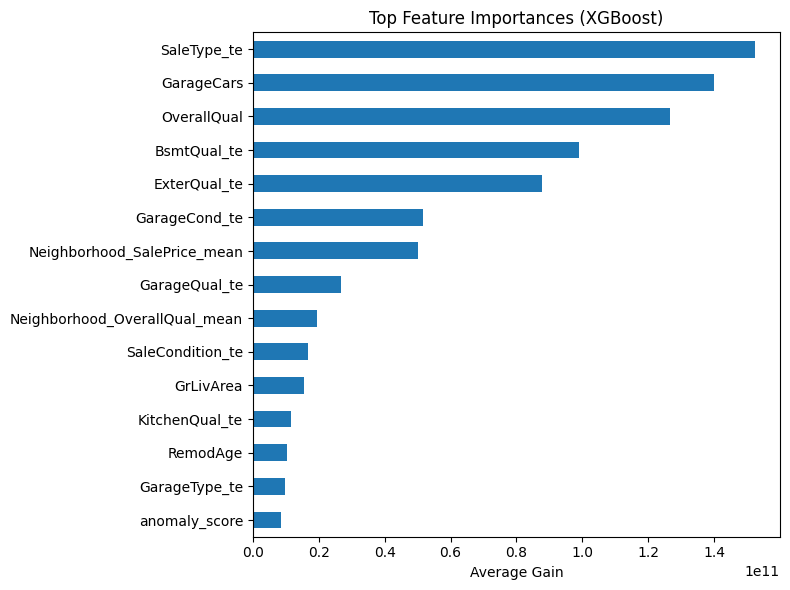

In [ ]:
top_n = 15

plt.figure(figsize=(8, 6))
importance.head(top_n).iloc[::-1].plot(kind='barh')
plt.xlabel("Average Gain")
plt.title("Top Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

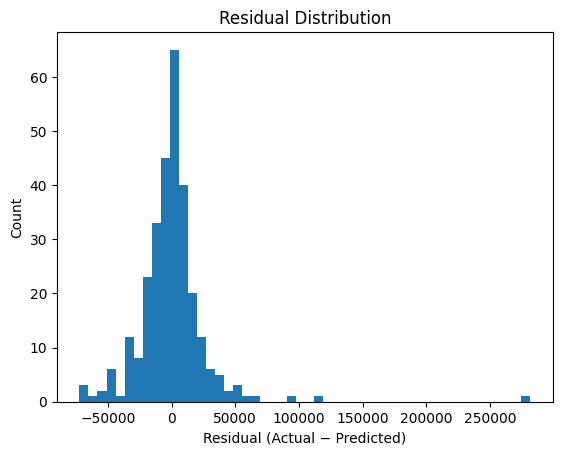

In [ ]:
residuals = y_test - y_pred
plt.figure()
plt.hist(residuals, bins=50)
plt.xlabel("Residual (Actual − Predicted)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.show()

# If you think about reasons for overprediction/ underprediction , it is because most models try to generalize - a core feature of ML Algorithms. Sometimes, they may generalize too much.

# Here is another idea - what if we can cluster houses and build models for each cluster? Then, we wouldnt be under/overpredicting in an attempt to generalize on the entire set of targets.

# It will generalize within clusters

# Let us evaluate options - dbscan - we have already detected outliers using anomaly detection. So lets not make things more complicated for now

# gmm - Gives us probabilities which can be used as input into our model. For time being, we want clear clusters without overlapping for the time being. Maybe we can try this a little later (maybe figure out a way to handle overlapping/border cases)

# Kmeans - this gives hard , strict, simple clusters

# hierarchical - gives us flexibility but takes too much time to tune

In [ ]:
cluster_features = [
    'OverallQual',
    'GrLivArea',
    'TotalBsmtSF',
    'GarageArea',
    'HouseAge',
]

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
X_cluster_train = scaler.fit_transform(train_df[cluster_features])
X_cluster_test  = scaler.transform(test_df[cluster_features])

In [ ]:
inertias = []
sil_scores = []
K = range(2, 8)  # Silhouette undefined for k=1

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++'
    )
    labels = kmeans.fit_predict(X_cluster_train)  # fits and predicts once
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X_cluster_train, labels)
    sil_scores.append(score)

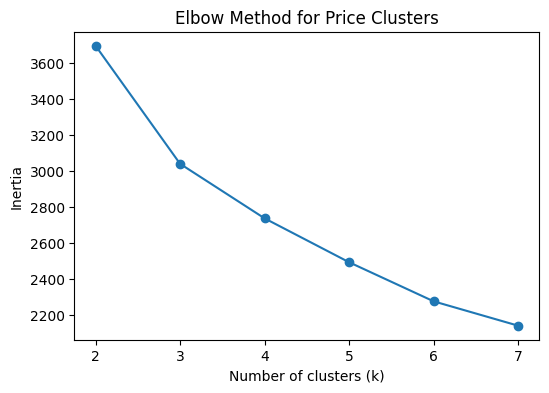

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Price Clusters')
plt.show()

Text(0.5, 1.0, 'Silhouette Score')

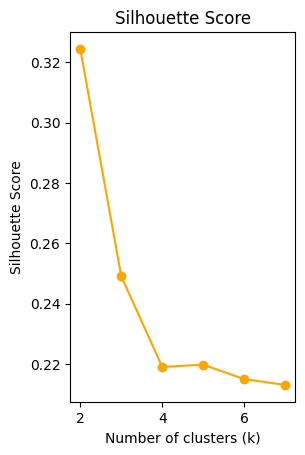

In [ ]:
plt.subplot(1, 2, 2)
plt.plot(K, sil_scores, marker='o', color='orange')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

In [ ]:
k_opt = 2

kmeans_final = KMeans(
    n_clusters=k_opt,
    init='k-means++',
)

train_df['price_cluster'] = kmeans_final.fit_predict(X_cluster_train)
test_df['price_cluster']  = kmeans_final.predict(X_cluster_test)

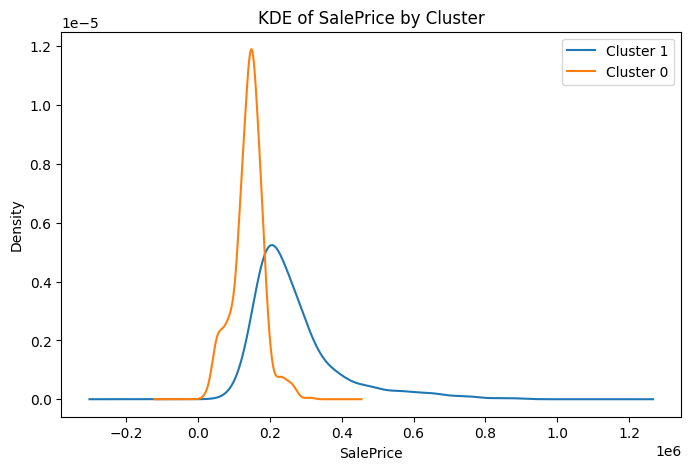

In [ ]:
plt.figure(figsize=(8, 5))

for cluster in train_df['price_cluster'].unique():
    subset = train_df[train_df['price_cluster'] == cluster]
    subset['SalePrice'].plot(kind='kde', label=f'Cluster {cluster}')

plt.xlabel('SalePrice')
plt.ylabel('Density')
plt.title('KDE of SalePrice by Cluster')
plt.legend()
plt.show()

In [ ]:
cluster_features = [
    'OverallQual',
    'GrLivArea',
    'TotalBsmtSF',
    'GarageArea',
    'HouseAge'
]

In [ ]:
train_df.groupby('price_cluster')[cluster_features].mean()

,OverallQual,GrLivArea,TotalBsmtSF,GarageArea,HouseAge
price_cluster,,,,,
0,5.255952,1280.462798,851.875000,369.142857,53.028274
1,7.264113,1857.137097,1327.002016,623.381048,13.112903


In [ ]:
target_col = 'SalePrice'

numeric_features = train_df.select_dtypes(include='number').columns.tolist()
numeric_features.remove(target_col)
numeric_features.remove('price_cluster')  # IMPORTANT

X_train_all = train_df[numeric_features]
y_train_all = train_df[target_col]

X_test_all = test_df[numeric_features]
y_test = test_df[target_col]

In [ ]:
import xgboost as xgb
import numpy as np

cluster_models = {}

for c in sorted(train_df['price_cluster'].unique()):
    cluster_data = train_df[train_df['price_cluster'] == c]

    X_c = cluster_data[numeric_features]
    y_c = cluster_data[target_col]

    model = xgb.XGBRegressor(
        n_estimators=700,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.5,
        colsample_bytree=0.2,
        random_state=42
    )

    model.fit(X_c, y_c)
    cluster_models[c] = model

In [ ]:
test_preds = np.zeros(len(test_df))

for c, model in cluster_models.items():
    idx = test_df['price_cluster'] == c
    test_preds[idx] = model.predict(X_test_all.loc[idx])

In [ ]:
for c in sorted(test_df['price_cluster'].unique()):
    idx = test_df['price_cluster'] == c
    mape_c = mean_absolute_percentage_error(y_test[idx], test_preds[idx])
    print(f"Cluster {c} MAPE: {mape_c:.4f}")

Cluster 0 MAPE: 0.1054
Cluster 1 MAPE: 0.0753


In [ ]:
mape = mean_absolute_percentage_error(y_test, test_preds)
print(f"Overall MAPE (clustered models): {mape:.4f}")

Overall MAPE (clustered models): 0.0933


In [ ]:
test_df['price_cluster'].value_counts()

,count
price_cluster,
0,175
1,117


In [ ]:
eval_df = test_df.copy()
eval_df['y_pred_model_1'] = y_pred
eval_df['y_pred_model_2'] = test_preds

In [ ]:
alphas = np.linspace(0, 1, 21)  # 0.0, 0.05, ..., 1.0
mape_scores = []

for alpha in alphas:
    y_pred_ensemble = (
        alpha * eval_df['y_pred_model_1'] +
        (1 - alpha) * eval_df['y_pred_model_2']
    )

    mape = mean_absolute_percentage_error(
        eval_df[target_col],
        y_pred_ensemble
    )

    mape_scores.append(mape)

results_df = pd.DataFrame({
    'alpha': alphas,
    'mape': mape_scores
})

results_df.sort_values('mape').head()

,alpha,mape
8,0.40,0.091124
7,0.35,0.091166
9,0.45,0.091188
6,0.30,0.091272
10,0.50,0.091402


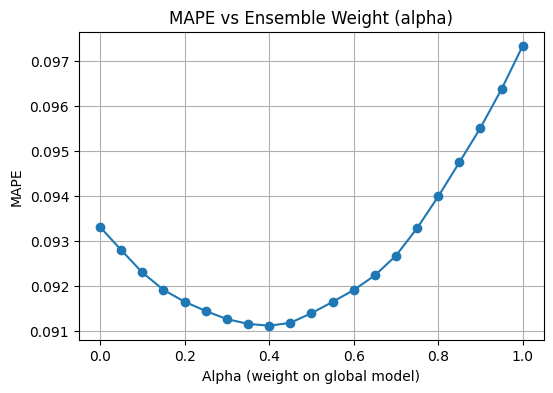

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(results_df['alpha'], results_df['mape'], marker='o')
plt.xlabel("Alpha (weight on global model)")
plt.ylabel("MAPE")
plt.title("MAPE vs Ensemble Weight (alpha)")
plt.grid(True)
plt.show()


In [ ]:
eval_df['final_pred'] = 0.4*eval_df['y_pred_model_1']+0.6*eval_df['y_pred_model_2']

# Post modelling Analysis

# It is important for us to understand scenarios in which our model is performing well vs is not performing well

# Why? We can communicate potential improvement areas to the stakeholder - helps buy more time. We can also set realisitc expectations - we are confident we can get house a, house b, house c right but not confident about house d

# First lets look at mape for anomalies vs non anomalies

In [ ]:
list(eval_df.columns)

['Id',
 'MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF'

In [ ]:
eval_df['is_anomaly'] = (iso.predict(eval_df[anomaly_features]) == -1).astype(int)

eval_df['is_anomaly'] = (iso.predict(eval_df[anomaly_features]) == -1).astype(int)

In [ ]:
for flag, name in [(0, 'Non-anomalies'), (1, 'Anomalies')]:
    subset = eval_df[eval_df['is_anomaly'] == flag]

    if len(subset) == 0:
        print(f"{name}: no samples")
        continue

    mape = mean_absolute_percentage_error(
        subset[target_col],
        subset['final_pred']
    )

    print(f"{name} | MAPE: {mape:.4f} | n={len(subset)}")

Non-anomalies | MAPE: 0.0904 | n=284
Anomalies | MAPE: 0.1181 | n=8


# Next, let us confirm if predictions and actuals are correlated. A good model will ensure if if actuals are high, predicted are also high and actuals are low, predicted are also low. For that, the datapoints for actual vs predicted should lie on a straight line

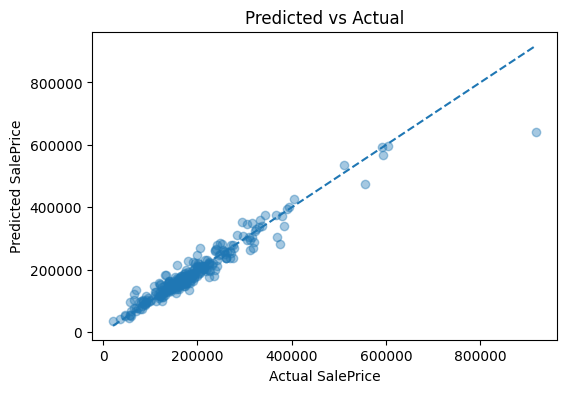

In [ ]:
eval_df['ape'] = np.abs(eval_df[target_col] - eval_df['final_pred']) / eval_df[target_col]

plt.figure(figsize=(6,4))
plt.scatter(eval_df[target_col], eval_df['final_pred'], alpha=0.4)
plt.plot(
    [eval_df[target_col].min(), eval_df[target_col].max()],
    [eval_df[target_col].min(), eval_df[target_col].max()],
    '--'
)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Predicted vs Actual")
plt.show()

# What priced homes is the model truly struggling with? Distribution of residual will only tell us direction of extreme errors, but dont tell us overall numbers on an average

/tmp/ipykernel_12930/3836509166.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: mean_absolute_percentage_error(x[target_col], x['final_pred']))


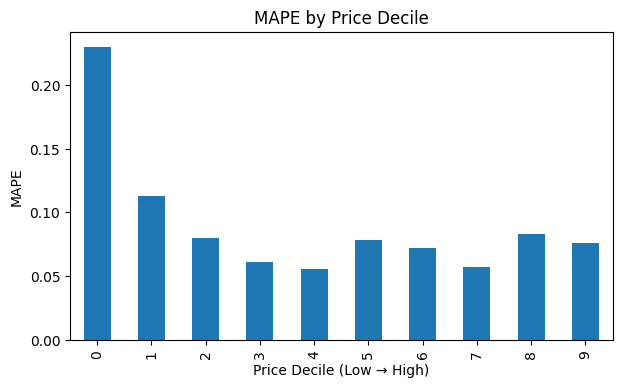

In [ ]:
eval_df['price_decile'] = pd.qcut(eval_df[target_col], 10, labels=False)

decile_mape = (
    eval_df
    .groupby('price_decile')
    .apply(lambda x: mean_absolute_percentage_error(x[target_col], x['final_pred']))
)

decile_mape.plot(kind='bar', figsize=(7,4))
plt.ylabel("MAPE")
plt.xlabel("Price Decile (Low → High)")
plt.title("MAPE by Price Decile")
plt.show()

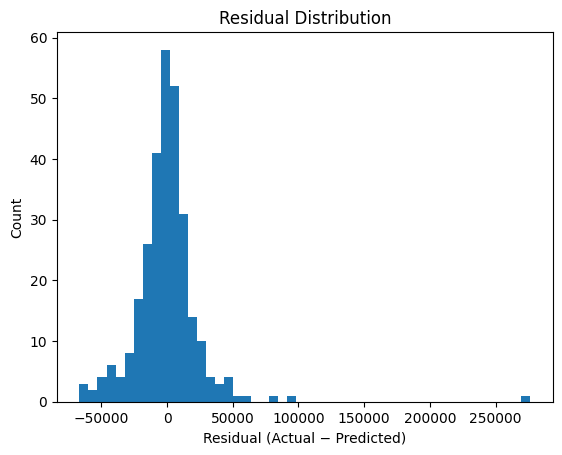

In [ ]:
residuals = eval_df['SalePrice'] - eval_df['final_pred']
plt.figure()
plt.hist(residuals, bins=50)
plt.xlabel("Residual (Actual − Predicted)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.show()

In [ ]:
eval_df[eval_df['price_decile']==0][['SalePrice','final_pred']]

,SalePrice,final_pred
22,20940.0,34613.668555
35,68621.3,135266.586719
48,90750.0,115541.383594
52,64500.0,104784.858594
63,66000.0,122727.364062
66,74400.0,78326.429688
69,83600.0,102345.000781
71,36600.0,43481.930859
75,85800.0,91635.270312
91,90200.0,94574.736719


In [ ]:
eval_df[eval_df['price_decile']==9][['SalePrice','final_pred']]

,SalePrice,final_pred
4,325000.0,329346.928125
8,315000.0,349338.221875
12,604291.5,597699.396875
15,312450.0,294455.415625
18,382850.0,339998.662500
27,297000.0,309586.148438
37,395152.5,401258.546875
40,344184.0,375949.803125
44,555000.0,476023.556250
46,375000.0,283149.350000


# Next, lets look at our model performance by neighborhood

In [ ]:
top10_nbhd = (
    eval_df['Neighborhood']
    .value_counts()
    .head(10)
    .index
)

In [ ]:
nbhd_mape = (
    eval_df[eval_df['Neighborhood'].isin(top10_nbhd)]
    .groupby('Neighborhood')
    .apply(lambda x: pd.Series({
        'MAPE': mean_absolute_percentage_error(x[target_col], x['final_pred']),
        'count': len(x)
    }))
    .sort_values('MAPE', ascending=False)
)

/tmp/ipykernel_760/215735257.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


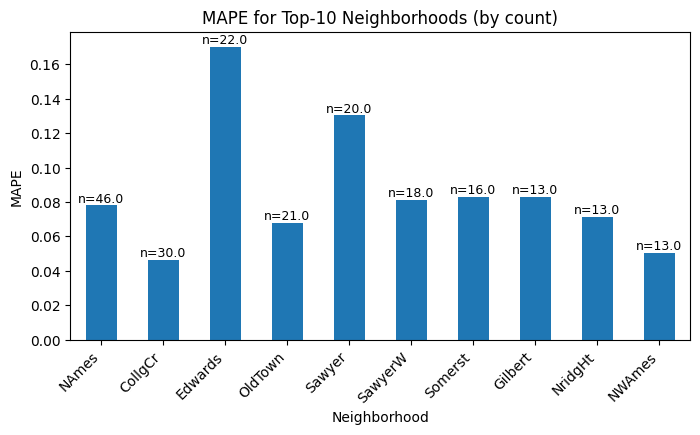

In [ ]:
nbhd_mape_sorted = nbhd_mape.sort_values(by='count', ascending=False)

ax = nbhd_mape_sorted['MAPE'].plot(
    kind='bar',
    figsize=(8,4)
)

plt.ylabel("MAPE")
plt.xlabel("Neighborhood")
plt.title("MAPE for Top-10 Neighborhoods (by count)")
plt.xticks(rotation=45, ha='right')

# Add counts on bars
for i, cnt in enumerate(nbhd_mape_sorted['count']):
    ax.text(
        i,
        ax.patches[i].get_height(),
        f"n={cnt}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.show()

# It would be useful to know whether our model does better for newer homes than older homes

/tmp/ipykernel_760/3357388020.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('HouseAge_bin')
/tmp/ipykernel_760/3357388020.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


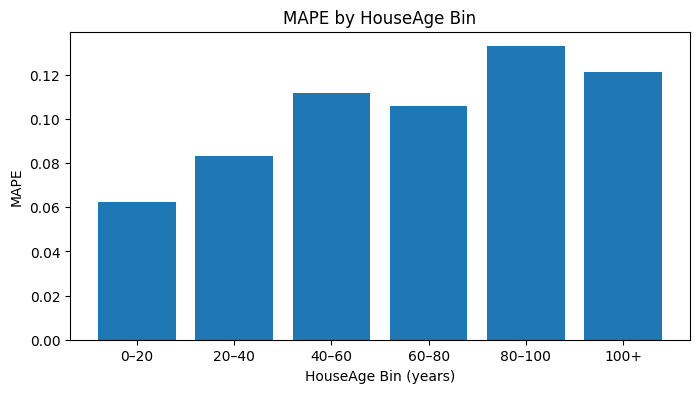

In [ ]:
# Define custom bins
bins = [0, 20, 40, 60, 80, 100, np.inf]
labels = ['0–20', '20–40', '40–60', '60–80', '80–100', '100+']

eval_df['HouseAge_bin'] = pd.cut(
    eval_df['HouseAge'],
    bins=bins,
    labels=labels,
    right=False
)

# Compute MAPE per bin
bin_stats = (
    eval_df
    .groupby('HouseAge_bin')
    .apply(lambda x: pd.Series({
        'MAPE': mean_absolute_percentage_error(x[target_col], x['final_pred']),
        'count': len(x)
    }))
)

# Plot
plt.figure(figsize=(8,4))
plt.bar(
    bin_stats.index.astype(str),
    bin_stats['MAPE']
)

plt.xlabel("HouseAge Bin (years)")
plt.ylabel("MAPE")
plt.title("MAPE by HouseAge Bin")
plt.show()



# Always good to inspect houses with highest errors - we can suggest the company to inspect these houses personally and see why they are underpriced or overpriced when compared to model predictions. Sometimes, our model may be right - just that some other odd factor playing a role in the price of the house

In [ ]:
eval_df.sort_values('ape', ascending=False).head(10)[
    ['Id', target_col, 'final_pred', 'ape',
     'Neighborhood', 'OverallQual']
]

,Id,SalePrice,final_pred,ape,Neighborhood,OverallQual
22,496,20940.0,78219.212109,2.735397,IDOTRR,4
71,376,36600.0,83765.396875,1.288672,Edwards,1
201,251,45900.0,93977.962500,1.047450,BrkSide,3
198,615,45300.0,89751.407031,0.981267,MeadowV,4
63,411,66000.0,129050.341406,0.955308,Edwards,5
35,463,68621.3,132105.479297,0.925138,Sawyer,5
261,813,55993.0,107524.534766,0.920321,IDOTRR,5
52,1293,64500.0,118093.778125,0.830911,OldTown,5
127,1012,60000.0,109000.819922,0.816680,Edwards,5
276,961,69900.0,123615.662500,0.768464,BrkSide,5


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

# Drop ID (no predictive value)

# Target
y = df['SalePrice']
X = df.drop(columns=['SalePrice'])

# Encode categorical features (no null handling)
cat_cols = X.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    # Fill NaN temporarily as string (NOT imputation, just encoding workaround)
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# XGBoost model (handles missing values natively)
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mape = np.sqrt(mean_absolute_percentage_error(y_test, y_pred))
print("mape:", mape)

mape: 0.32264026515358657
